In [51]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [88]:
vaccelerate_shares = pd.read_csv("../../data/raw/vaccelerate_pathogen_arrival_shares.csv")
homebrewed_shares = pd.read_csv("../../data/raw/homebrewed_pathogen_arrival_shares.csv")
viral_family_overview = pd.read_csv("../../data/raw/Viral family review - Viral family summary.csv")

In [89]:
vaccelerate_shares['pathogen_group'] = vaccelerate_shares['pathogen'].copy()
vaccelerate_shares['pathogen_group'] = vaccelerate_shares['pathogen_group'].str.replace('Other pathogens', 'Other viruses')

In [90]:
homebrewed_shares['pathogen_group'] = homebrewed_shares['pathogen'].copy()

homebrewed_shares['pathogen_group'] = homebrewed_shares['pathogen_group'].str.replace('Flu', 'Influenza')
homebrewed_shares['pathogen_group'] = homebrewed_shares['pathogen_group'].str.replace('Covid-19', 'SARS-CoV-2')
homebrewed_shares['pathogen_group'] = homebrewed_shares['pathogen_group'].str.replace('Other coronavirus (not MERS)', 'SARS-CoV')
homebrewed_shares['pathogen_group'] = homebrewed_shares['pathogen_group'].str.replace('MERS', 'MERS-CoV')
homebrewed_shares['pathogen_group'] = homebrewed_shares['pathogen_group'].str.replace('Totally unknown virus', 'Disease X')
homebrewed_shares['pathogen_group'] = homebrewed_shares['pathogen_group'].str.replace(' (e.g., parasite, or fungus, please specify)', '')
homebrewed_shares['pathogen_group'] = homebrewed_shares['pathogen_group'].str.replace('l infection', '')

other_pathogen_idx = homebrewed_shares['pathogen'].isin(['Crimean-Congo haemorrhagic fever', 'Lassa', 'Nipah', 
                                                         'Rift Valley Fever', 'Chikungunya',  'Other known virus (please specify)'])
homebrewed_shares.loc[other_pathogen_idx, 'pathogen_group'] = 'Other viruses'
homebrewed_shares

,pathogen,arrival_share,pathogen_group
0,Covid-19,0.03,SARS-CoV-2
1,Crimean-Congo haemorrhagic fever,0.01,Other viruses
2,MERS,0.04,MERS-CoV
3,Lassa,0.02,Other viruses
4,Nipah,0.05,Other viruses
5,Rift Valley Fever,0.03,Other viruses
6,Chikungunya,0.05,Other viruses
7,Ebola,0.03,Ebola
8,Zika,0.06,Zika
9,Flu,0.28,Influenza


In [91]:
homebrewed_shares_grouped = homebrewed_shares.groupby('pathogen_group')['arrival_share'].sum()

C:\Users\squaade\AppData\Local\Temp\ipykernel_29212\603647588.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right', fontsize=11)


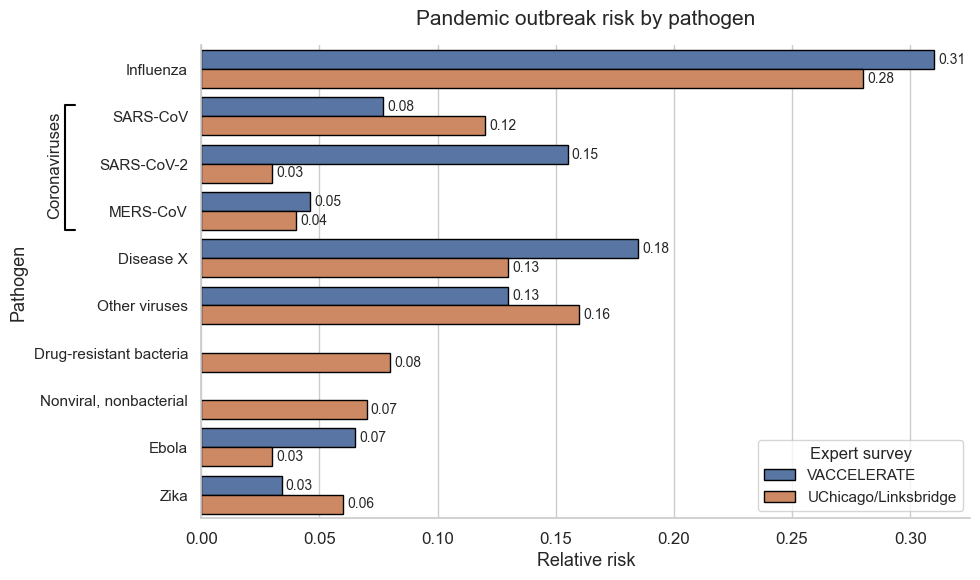

In [92]:
# Prepare data for plotting (prettier version, horizontal bars)

# Harmonize column names
vaccelerate_plot = vaccelerate_shares[['pathogen_group', 'share']].copy()
vaccelerate_plot['source'] = 'VACCELERATE'
vaccelerate_plot = vaccelerate_plot.rename(columns={'share': 'share_value'})

homebrewed_plot = homebrewed_shares.groupby('pathogen_group', as_index=False)['arrival_share'].sum()
homebrewed_plot['source'] = 'UChicago/Linksbridge'
homebrewed_plot = homebrewed_plot.rename(columns={'arrival_share': 'share_value'})

# Concatenate for plotting
plot_df = pd.concat([vaccelerate_plot, homebrewed_plot], ignore_index=True)

# Identify coronavirus groups
coronavirus_groups = ['SARS-CoV-2', 'SARS-CoV', 'MERS-CoV']

# Sort pathogen groups: coronaviruses together, placed in the order of their own mean, but the block is positioned according to the sum of their means among all groups
mean_shares = plot_df.groupby('pathogen_group')['share_value'].mean()

# Calculate the sum of means for coronavirus groups
corona_sum = mean_shares[mean_shares.index.isin(coronavirus_groups)].sum()

# Get non-coronavirus groups and their means
other_means = mean_shares[~mean_shares.index.isin(coronavirus_groups)].sort_values(ascending=False)

# Find where the coronavirus block should go (by comparing corona_sum to other group means)
insert_idx = (other_means >= corona_sum).sum()

# Sort coronavirus groups by their own mean (descending)
corona_sorted = mean_shares[mean_shares.index.isin(coronavirus_groups)].sort_values(ascending=False)

# Build the final order: others before, then all coronaviruses, then others after
sorted_pathogen_groups = (
    list(other_means.index[:insert_idx]) +
    list(corona_sorted.index) +
    list(other_means.index[insert_idx:])
)

# Set seaborn style
palette = {"VACCELERATE": "#4C72B0", "UChicago/Linksbridge": "#DD8452"}

fig, ax = plt.subplots(figsize=(10, 6))

# Draw horizontal bars
sns.barplot(
    data=plot_df,
    y='pathogen_group',
    x='share_value',
    hue='source',
    order=sorted_pathogen_groups,
    ax=ax,
    palette=palette,
    edgecolor="black",
    orient='h'
)

# Add value labels at the end of bars
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3, fontsize=10, label_type='edge')

# Prettify axes and legend
ax.set_xlabel("Relative risk", fontsize=13)
ax.set_ylabel("Pathogen", fontsize=13)
ax.set_title("Pandemic outbreak risk by pathogen", fontsize=15, pad=15)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right', fontsize=11)
ax.legend(title="Expert survey", fontsize=11, title_fontsize=12, frameon=True, loc='lower right')

# Draw a bracket and label OUTSIDE the plot area, to the left of the coronavirus bar labels
ytick_labels = [tick.get_text() for tick in ax.get_yticklabels()]
corona_ys = [i for i, label in enumerate(ytick_labels) if label in coronavirus_groups]
if corona_ys:
    y0 = min(corona_ys)
    y1 = max(corona_ys)
    # Use figure coordinates to place the bracket and label outside the axes
    # Get axes position in figure coordinates
    ax_pos = ax.get_position()
    fig_x0 = ax_pos.x0
    fig_y0 = ax_pos.y0
    fig_height = ax_pos.height

    # Calculate the vertical position of the bracket in figure coordinates
    n_labels = len(ytick_labels)
    # y0 and y1 are indices in the ytick_labels list (from top to bottom)
    # In matplotlib, y=0 is bottom, so we need to invert
    def yidx_to_figfrac(yidx):
        # yidx=0 is top, so invert
        return fig_y0 + fig_height * (1 - (yidx + 0.5) / n_labels)

    # Make the bracket a bit taller so it hugs the labels more
    bracket_pad = 0.35  # in label units; increase for more padding
    bracket_y0 = yidx_to_figfrac(y0 - bracket_pad)
    bracket_y1 = yidx_to_figfrac(y1 + bracket_pad)
    bracket_yc = (bracket_y0 + bracket_y1) / 2 + 0.02

    # Move the bracket and label a bit closer to the labels
    bracket_x = fig_x0 - 0.05  # was fig_x0, now closer
    bracket_x_label = bracket_x - 0.018  # was -0.025, now closer

    # Bracket parameters
    bracket_height = abs(bracket_y1 - bracket_y0)
    bracket_width = 0.010  # slightly narrower

    # Draw the bracket as a path (left, down, up, right)
    bracket_path = [
        (bracket_x, bracket_y0),
        (bracket_x - bracket_width, bracket_y0),
        (bracket_x - bracket_width, bracket_y1),
        (bracket_x, bracket_y1),
    ]
    # Convert to display coordinates
    bracket_disp = fig.transFigure.transform(bracket_path)
    bracket_line = plt.Line2D(
        bracket_disp[:, 0], bracket_disp[:, 1], color='black', lw=1.5, transform=None, clip_on=False
    )
    fig.add_artist(bracket_line)

    # Add the label vertically centered beside the bracket
    fig.text(
        bracket_x_label,
        bracket_yc,
        "Coronaviruses",
        va='center',
        fontsize=12,
        rotation=90,
    )

sns.despine(ax=ax)
plt.tight_layout()
plt.show()
